# Bayesian conditioning on linear measurements

A Gaussian prior x~N(0,K) and measurement noise ε~N(0,R) imply a Gaussian posterior. For a general operator, μ=KAᵀ(AKAᵀ+R)⁻¹y. Its covariance shrinks where measurements constrain the field. A fixed kernel does not express all scientific uncertainty.

**Objective:** distinguish uncertainty from error.

In [1]:
from pathlib import Path
import os
if Path.cwd().name == 'tutorials': os.chdir('..')
import numpy as np
import matplotlib.pyplot as plt
from fieldlab import Grid, points, lines, footprints, projections, combine
from fieldlab.fields import simulate, sensor_layout
from fieldlab.operators import observe
from fieldlab.models import idw, tikhonov, gaussian_process, total_variation, heat_reconstruction


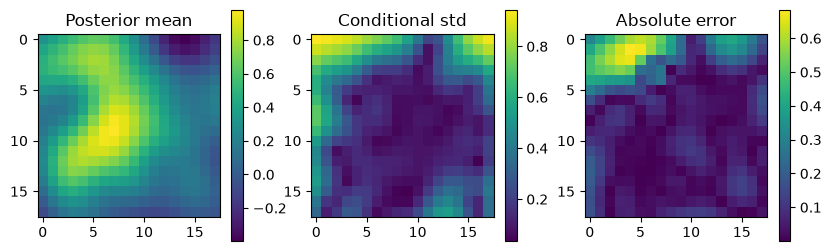

Pointwise 95% interval coverage: 0.9938271604938271


In [2]:
grid=Grid((18,18)); truth=simulate(grid,33)
A,layout=sensor_layout(grid,15,12,4,seed=4); y=observe(A,truth,.04,5)
r=gaussian_process(grid,A,y,noise=.04,length_scale=.18)
fig,axes=plt.subplots(1,3,figsize=(10,3))
for ax,name,f in zip(axes,['Posterior mean','Conditional std','Absolute error'],[r.mean,r.std,np.abs(r.mean-truth)]):
    im=ax.imshow(f); ax.set_title(name); fig.colorbar(im,ax=ax)
plt.show()
print('Pointwise 95% interval coverage:',np.mean(np.abs(r.mean-truth)<=1.96*r.std))
assert np.all(r.std>=0)


**Exercise:** repeat for length scales .04, .2, and .8. Is high confidence always justified? Add a sensor and check that posterior variance cannot increase under fixed assumptions. Explain why pointwise coverage differs from simultaneous field coverage.

See [theory notes](../docs/theory.md) for assumptions and equations.